# Dubins — three-method comparison figures (one-shot paper figures)

Regenerates, in one run, the Dubins paper figures comparing **vanilla MPC**,
**reach-avoid MPC (RA-MPC)** and the **unconstrained controller**, reusing the exact
settings of the three individual `example_dubins_car_*` notebooks.

Figures written to `figures/` as `.pdf` (paper) + `.png` (preview):

- `fig_dubins_vanilla`, `fig_dubins_rampc`, `fig_dubins_uncon` — per method: feasible
  region + the single closed-loop trajectory from a shared initial point (+ k1 field for
  the two reach-avoid methods).
- `fig_dubins_compare` — RA-MPC success rate vs sampling time (top) + control-input
  comparison u1/u2 (uncon continuous vs RA-MPC ZOH) from the shared initial point.

**Unified feasibility:** a start is feasible iff the method safely reaches the target —
vanilla MPC within its N=25 (1.25 s) horizon (target terminal); RA-MPC's receding closed
loop (cert terminal) within 10 s; the unconstrained controller's closed loop within 10 s.

Run with the **rab_mpc** kernel. First run is slow (RA-MPC receding feasibility + the dt
sweep); results are cached under `figures/`.


In [2]:
# ── Repo-root bootstrap ───────────────────────────────────────────────────────
import os
import sys

ROOT = os.getcwd()
for _ in range(4):
    if os.path.isdir(os.path.join(ROOT, "controllers")) and os.path.isdir(
        os.path.join(ROOT, "matlab")
    ):
        break
    ROOT = os.path.dirname(ROOT)
for _sub in ("controllers", "python"):
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
OUTDIR = os.path.join(ROOT, "figures")
os.makedirs(OUTDIR, exist_ok=True)
print("ROOT  =", ROOT)
print("OUTDIR=", OUTDIR)

ROOT  = /home/jianqiang/Downloads/reach_avoid_backstepping_MPC
OUTDIR= /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/figures


In [3]:
# ── Parameters ────────────────────────────────────────────────────────────────
X0_SHARED = (
    None  # set a length-4 [x1, x2, th, v] to fix the shared start; None -> auto-pick
)
RECOMPUTE_FEAS = False  # True to ignore the cached feasibility / sweep results
N_CANDIDATES = 300  # candidates for the feasibility figures
N_SWEEP_CAND = 150  # (smaller) candidate subset for the dt sweep
DT_SWEEP = [0.025, 0.05, 0.125, 0.25]  # N = round(T_HOR/dt) = [50, 25, 10, 5]
T_HOR = 1.25  # fixed prediction-horizon time (dt * N)
T_MAX = 10.0  # closed-loop reach-avoid window [s]
SEED = 42
DT_BASE, N_BASE = 0.05, 25

In [4]:
# ── Load controllers + symbols / dynamics / sets (same as the example notebooks)
import numpy as np
import sympy as sp
import casadi as ca
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from sop_bounded_control_dubins_car_result import certificate_opt, k1_opt as k1_ra
from sop_bounded_control_dubins_car_unconstrained import (
    u_opt as u_unc,
    k1_opt as k1_unc,
)

x1, x2, th, v = sp.symbols("x1 x2 th v")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, th, v]
f_sym = sp.Matrix([v * sp.cos(th), v * sp.sin(th), 0, 0])
g_sym = sp.Matrix([[0, 0], [0, 0], [1, 0], [0, 1]])
hx = sp.Matrix([x1, x2])
h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
target_set_y = (y2 - 0) ** 2 + (2 * (y1 + 1.7)) ** 2 - 0.4
alpha = 1e-3 * (-target_set_y + 300)
safe_set_y = alpha * h_raw
safe_set_x = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})
u_unc = sp.Matrix(u_unc)

safe_x_f = sp.lambdify(state_vars, safe_set_x, "numpy")
target_x_f = sp.lambdify(state_vars, target_set_x, "numpy")
u_unc_f = sp.lambdify(state_vars, list(u_unc), "numpy")
safe_y_f = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_y_f = sp.lambdify([y1, y2], target_set_y, "numpy")

u1_max = u2_max = 5.0
U_MAX = (u1_max, u2_max)
TARGET_POS = np.array([-1.7, 0.0])
Q_y, Qf_y, R_u = 5.0, 80.0, 0.05
IPOPT = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 500,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}
print("cert free symbols:", certificate_opt.free_symbols)

cert free symbols: {x2, v, x1, th}


In [5]:
# ── CasADi sets + parametric MPC (terminal = "target" for vanilla, "cert" for RA-MPC)
def _s2c(e, mp):
    if isinstance(
        e,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
        ),
    ):
        return float(e)
    if isinstance(e, sp.Symbol):
        return mp[e]
    if isinstance(e, sp.Add):
        return sum(_s2c(a, mp) for a in e.args)
    if isinstance(e, sp.Mul):
        r = 1.0
        for a in e.args:
            r = r * _s2c(a, mp)
        return r
    if isinstance(e, sp.Pow):
        return _s2c(e.args[0], mp) ** _s2c(e.args[1], mp)
    if isinstance(e, sp.sin):
        return ca.sin(_s2c(e.args[0], mp))
    if isinstance(e, sp.cos):
        return ca.cos(_s2c(e.args[0], mp))
    if isinstance(e, sp.Number):
        return float(e)
    raise ValueError(type(e))


_cx = [ca.SX.sym(n) for n in ("x1", "x2", "th", "v")]
_mp = {x1: _cx[0], x2: _cx[1], th: _cx[2], v: _cx[3]}
cert_f = ca.Function("cert", _cx, [_s2c(certificate_opt, _mp)])
safe_cf = ca.Function("safe", _cx, [_s2c(safe_set_x, _mp)])
_uc = ca.SX.sym("u", 2)
_xs = ca.vertcat(*_cx)
fc_f = ca.Function(
    "fc",
    [_xs, _uc],
    [ca.vertcat(_cx[3] * ca.cos(_cx[2]), _cx[3] * ca.sin(_cx[2]), _uc[0], _uc[1])],
)


def safe_ca(x):
    return safe_cf(x[0], x[1], x[2], x[3])


def cert_ca(x):
    return cert_f(x[0], x[1], x[2], x[3])


def target_ca(x):
    return (x[1]) ** 2 + (2 * (x[0] + 1.7)) ** 2 - 0.4


def _rk4(step_fn, xk, uk, dt):
    k1 = step_fn(xk, uk)
    k2 = step_fn(xk + dt / 2 * k1, uk)
    k3 = step_fn(xk + dt / 2 * k2, uk)
    k4 = step_fn(xk + dt * k3, uk)
    return xk + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


def rk4_np(x, u, dt):
    def f(xx):
        return np.array([xx[3] * np.cos(xx[2]), xx[3] * np.sin(xx[2]), u[0], u[1]])

    return _rk4(lambda xx, uu: f(xx), np.asarray(x, float), u, dt)


def zoh_step(x, u, dt):
    """Advance the TRUE continuous dynamics over [0, dt] under the constant (ZOH)
    control u, via fine RK4 substeps. This is the realistic sampled closed-loop
    step: the MPC plans with the coarse-dt model but the plant evolves continuously,
    so coarser sampling (larger dt) incurs a real model mismatch."""
    nsub = max(1, int(round(dt / 0.005)))
    h = dt / nsub
    x = np.asarray(x, float)
    for _ in range(nsub):
        x = rk4_np(x, u, h)
    return x


import time as _time

SOLVE_MS = {
    "target": [],
    "cert": [],
}  # per-step opti.solve() wall times [ms], by terminal


def solve_mpc(x0, terminal, dt=DT_BASE, N=N_BASE, U_warm=None):
    opti = ca.Opti()
    X = opti.variable(4, N + 1)
    U = opti.variable(2, N)
    x0 = np.asarray(x0, float).flatten()
    opti.subject_to(X[:, 0] == x0)
    for k in range(N):
        opti.subject_to(X[:, k + 1] == _rk4(fc_f, X[:, k], U[:, k], dt))
        opti.subject_to(safe_ca(X[:, k]) >= 0)
    opti.subject_to(safe_ca(X[:, N]) >= 0)
    if terminal == "target":
        opti.subject_to(target_ca(X[:, N]) <= 0)
    else:
        opti.subject_to(cert_ca(X[:, N]) >= 0)
    opti.subject_to(opti.bounded(-u1_max, U[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U[1, :], u2_max))
    tgt = ca.DM(TARGET_POS)
    cost = 0
    for k in range(N):
        dy = X[:2, k] - tgt
        cost += Q_y * ca.dot(dy, dy) + R_u * ca.dot(U[:, k], U[:, k])
    dyN = X[:2, N] - tgt
    cost += Qf_y * ca.dot(dyN, dyN)
    opti.minimize(cost)
    if U_warm is not None and U_warm.shape[1] == N:
        Uws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
        Xws = np.zeros((4, N + 1))
        Xws[:, 0] = x0
        for k in range(N):
            Xws[:, k + 1] = rk4_np(Xws[:, k], Uws[:, k], dt)
        opti.set_initial(X, Xws)
        opti.set_initial(U, Uws)
    else:
        tgt_full = np.array([TARGET_POS[0], TARGET_POS[1], x0[2], 0.0])
        Xws = np.array([(1 - k / N) * x0 + (k / N) * tgt_full for k in range(N + 1)]).T
        opti.set_initial(X, Xws)
        opti.set_initial(U, 0)
    opti.solver("ipopt", IPOPT)
    try:
        _t0 = _time.perf_counter()
        sol = opti.solve()
        SOLVE_MS.setdefault(terminal, []).append((_time.perf_counter() - _t0) * 1000.0)
        return (
            True,
            np.array(sol.value(U)).reshape(2, N),
            np.array(sol.value(X)).reshape(4, N + 1),
        )
    except Exception:
        return False, None, None

In [6]:
# ── Rollouts (return t, u, x) + the three feasibility predicates ──────────────
def rollout_mpc(x0, terminal, dt=DT_BASE, N=N_BASE, T_max=T_MAX):
    x = np.asarray(x0, float).copy()
    ts, us, xs = [0.0], [], [x.copy()]
    U_prev = None
    t = 0.0
    for _ in range(int(round(T_max / dt))):
        if float(np.squeeze(target_x_f(*x))) <= 0:
            break
        ok, U, _ = solve_mpc(x, terminal, dt=dt, N=N, U_warm=U_prev)
        if not ok:
            break
        U_prev = U
        u0 = U[:, 0]
        x = zoh_step(x, u0, dt)
        t += dt
        us.append(u0.copy())
        ts.append(t)
        xs.append(x.copy())
    return np.array(ts), np.array(us), np.array(xs)


def rollout_uncon(x0, T_max=T_MAX):
    def rhs(t, x):
        u = u_unc_f(*x)
        d = np.array(
            [x[3] * np.cos(x[2]), x[3] * np.sin(x[2]), float(u[0]), float(u[1])]
        )
        return d if np.all(np.isfinite(d)) else np.zeros(4)

    def ev(t, x):
        return float(np.squeeze(target_x_f(*x)))

    ev.terminal = True
    ev.direction = -1
    s = solve_ivp(
        rhs,
        (0, T_max),
        np.asarray(x0, float),
        method="DOP853",
        events=ev,
        rtol=1e-8,
        atol=1e-10,
        max_step=0.02,
        dense_output=True,
    )
    tt = np.linspace(0, s.t[-1], max(2, int(s.t[-1] / 0.02) + 1))
    xs = s.sol(tt).T
    us = np.array([u_unc_f(*xx) for xx in xs], float).reshape(len(tt), 2)
    return tt, us, xs


def feas_vanilla(x0):
    ok, _, _ = solve_mpc(x0, "target")
    return bool(ok)


def feas_rampc(x0, dt=DT_BASE, N=N_BASE, T_max=T_MAX):
    x = np.asarray(x0, float).copy()
    U_prev = None
    for _ in range(int(round(T_max / dt))):
        if float(np.squeeze(safe_x_f(*x))) < 0:
            return False
        if float(np.squeeze(target_x_f(*x))) <= 0:
            return True
        ok, U, _ = solve_mpc(x, "cert", dt=dt, N=N, U_warm=U_prev)
        if not ok:
            return False
        U_prev = U
        x = zoh_step(x, U[:, 0], dt)
        if not np.all(np.isfinite(x)):
            return False
    return bool(float(np.squeeze(target_x_f(*x))) <= 0)


def feas_uncon(x0, T_max=T_MAX):
    def rhs(t, x):
        u = u_unc_f(*x)
        d = np.array(
            [x[3] * np.cos(x[2]), x[3] * np.sin(x[2]), float(u[0]), float(u[1])]
        )
        return d if np.all(np.isfinite(d)) else np.zeros(4)

    def ev(t, x):
        return float(np.squeeze(target_x_f(*x)))

    ev.terminal = True
    ev.direction = -1
    s = solve_ivp(
        rhs,
        (0, T_max),
        np.asarray(x0, float),
        method="DOP853",
        events=ev,
        rtol=1e-7,
        atol=1e-9,
        max_step=0.02,
    )
    if s.status < 0 or not np.all(np.isfinite(s.y)):
        return False
    reached = s.status == 1
    safe_ok = np.all(np.atleast_1d(np.squeeze(safe_x_f(*s.y))) >= 0)
    return bool(reached and safe_ok)

In [7]:
# ── Sample candidates + classify feasibility for all three methods (cached) ──
from joblib import Parallel, delayed

np.random.seed(SEED)
lb = np.array([-2.0, -2.0, 2 * np.pi / 3, -1.0])
ub = np.array([2.0, 2.0, 4 * np.pi / 3, 1.0])
X = np.random.rand(4, 1000) * (ub - lb).reshape(-1, 1) + lb.reshape(-1, 1)
_safe = np.atleast_1d(np.squeeze(safe_x_f(*X)))
_tgt = np.atleast_1d(np.squeeze(target_x_f(*X)))
candidate_idx = np.where((_safe >= 0) & (_tgt > 0))[0][:N_CANDIDATES]
print(f"Candidates (safe & outside target): {len(candidate_idx)}")


def _sig():
    import hashlib

    parts = ["zoh", N_CANDIDATES, SEED, DT_BASE, N_BASE, T_MAX, u1_max, u2_max]
    for f in (
        "sop_bounded_control_dubins_car_result.py",
        "sop_bounded_control_dubins_car_unconstrained.py",
    ):
        parts.append(int(os.path.getmtime(os.path.join(ROOT, "controllers", f))))
    return hashlib.md5(repr(parts).encode()).hexdigest()


_cache = os.path.join(OUTDIR, "feasibility_cache.npz")
feas = None
if (not RECOMPUTE_FEAS) and os.path.exists(_cache):
    # self-written cache (plain int/bool arrays + a string sig); no pickle needed
    d = np.load(_cache)
    if (
        str(d["sig"]) == _sig()
        and d["candidate_idx"].shape == candidate_idx.shape
        and np.all(d["candidate_idx"] == candidate_idx)
    ):
        feas = {
            "Vanilla MPC": d["vanilla"],
            "RA-MPC": d["rampc"],
            "Unconstrained": d["uncon"],
        }
        print("loaded cached feasibility")

if feas is None:
    print("computing feasibility (this is the slow part) ...")
    fv = np.array(
        Parallel(n_jobs=-1, prefer="processes")(
            delayed(feas_vanilla)(X[:, i]) for i in candidate_idx
        ),
        dtype=bool,
    )
    fr = np.array(
        Parallel(n_jobs=-1, prefer="processes")(
            delayed(feas_rampc)(X[:, i]) for i in candidate_idx
        ),
        dtype=bool,
    )
    fu = np.array(
        Parallel(n_jobs=-1, prefer="threads")(
            delayed(feas_uncon)(X[:, i]) for i in candidate_idx
        ),
        dtype=bool,
    )
    feas = {"Vanilla MPC": fv, "RA-MPC": fr, "Unconstrained": fu}
    np.savez(
        _cache, sig=_sig(), candidate_idx=candidate_idx, vanilla=fv, rampc=fr, uncon=fu
    )

nc = len(candidate_idx)
for m, mask in feas.items():
    print(f"  {m:14s}: {int(mask.sum()):3d} / {nc}  ({100*mask.sum()/nc:.1f}%)")

Candidates (safe & outside target): 300
loaded cached feasibility
  Vanilla MPC   : 245 / 300  (81.7%)
  RA-MPC        : 255 / 300  (85.0%)
  Unconstrained :  94 / 300  (31.3%)


In [8]:
# ── Shared initial point + per-method rollouts from it ───────────────────────
all_ok = feas["Vanilla MPC"] & feas["RA-MPC"] & feas["Unconstrained"]
allok_idx = candidate_idx[all_ok]
assert allok_idx.size > 0, "no candidate is feasible under all three methods"

if X0_SHARED is not None:
    x0_shared = np.asarray(X0_SHARED, float)
    x0_id = -1
else:
    # farthest from the target (most informative trajectory) among all-3-feasible
    d2 = (X[0, allok_idx] - TARGET_POS[0]) ** 2 + (X[1, allok_idx] - TARGET_POS[1]) ** 2
    x0_id = int(allok_idx[np.argmax(d2)])
    x0_shared = X[:, x0_id].copy()
print(
    f"shared x0 (cand_id={x0_id}): {np.round(x0_shared, 3)}  "
    f"(all-3-feasible candidates: {allok_idx.size})"
)

TRAJ = {
    "Vanilla MPC": rollout_mpc(x0_shared, "target"),
    "RA-MPC": rollout_mpc(x0_shared, "cert"),
    "Unconstrained": rollout_uncon(x0_shared),
}
for m, (t, u, x) in TRAJ.items():
    reached = float(np.squeeze(target_x_f(*x[-1]))) <= 1e-6
    print(f"  {m:14s}: T={t[-1]:.2f}s  pts={len(t)}  reached={reached}")

shared x0 (cand_id=395): [1.723 1.316 2.819 0.992]  (all-3-feasible candidates: 78)

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

  Vanilla MPC   : T=1.20s  pts=25  reached=True
  RA-MPC        : T=1.20s  pts=25  reached=True
  Unconstrained : T=4.80s  pts=240  reached=True


In [9]:
# ── Average single-step MPC solve time (receding closed loop, warm-started) ──
# Time each opti.solve() over the receding RA-MPC / vanilla-MPC rollouts of a few
# all-3-feasible candidates; report the mean wall time per MPC step for each method.
_bench = allok_idx[: min(10, allok_idx.size)]
SOLVE_MS["target"].clear()
SOLVE_MS["cert"].clear()
for _i in _bench:
    rollout_mpc(X[:, _i], "target")
    rollout_mpc(X[:, _i], "cert")
_mt = np.array(SOLVE_MS["target"])
_mc = np.array(SOLVE_MS["cert"])
SOLVE_TIMING = {
    "Vanilla MPC": (float(_mt.mean()), float(_mt.std()), int(_mt.size)),
    "RA-MPC": (float(_mc.mean()), float(_mc.std()), int(_mc.size)),
}
print(
    f"Average single-step MPC solve time over {len(_bench)} receding rollouts "
    f"(dt={DT_BASE}, N={N_BASE}):"
)
for _m, (_mu, _sd, _n) in SOLVE_TIMING.items():
    print(f"  {_m:12s}: {_mu:6.1f} +/- {_sd:5.1f} ms/step   (n={_n} steps)")

Average single-step MPC solve time over 10 receding rollouts (dt=0.05, N=25):
  Vanilla MPC :   29.2 +/-   6.5 ms/step   (n=182 steps)
  RA-MPC      :   31.5 +/-  10.6 ms/step   (n=182 steps)


saved fig_dubins_vanilla


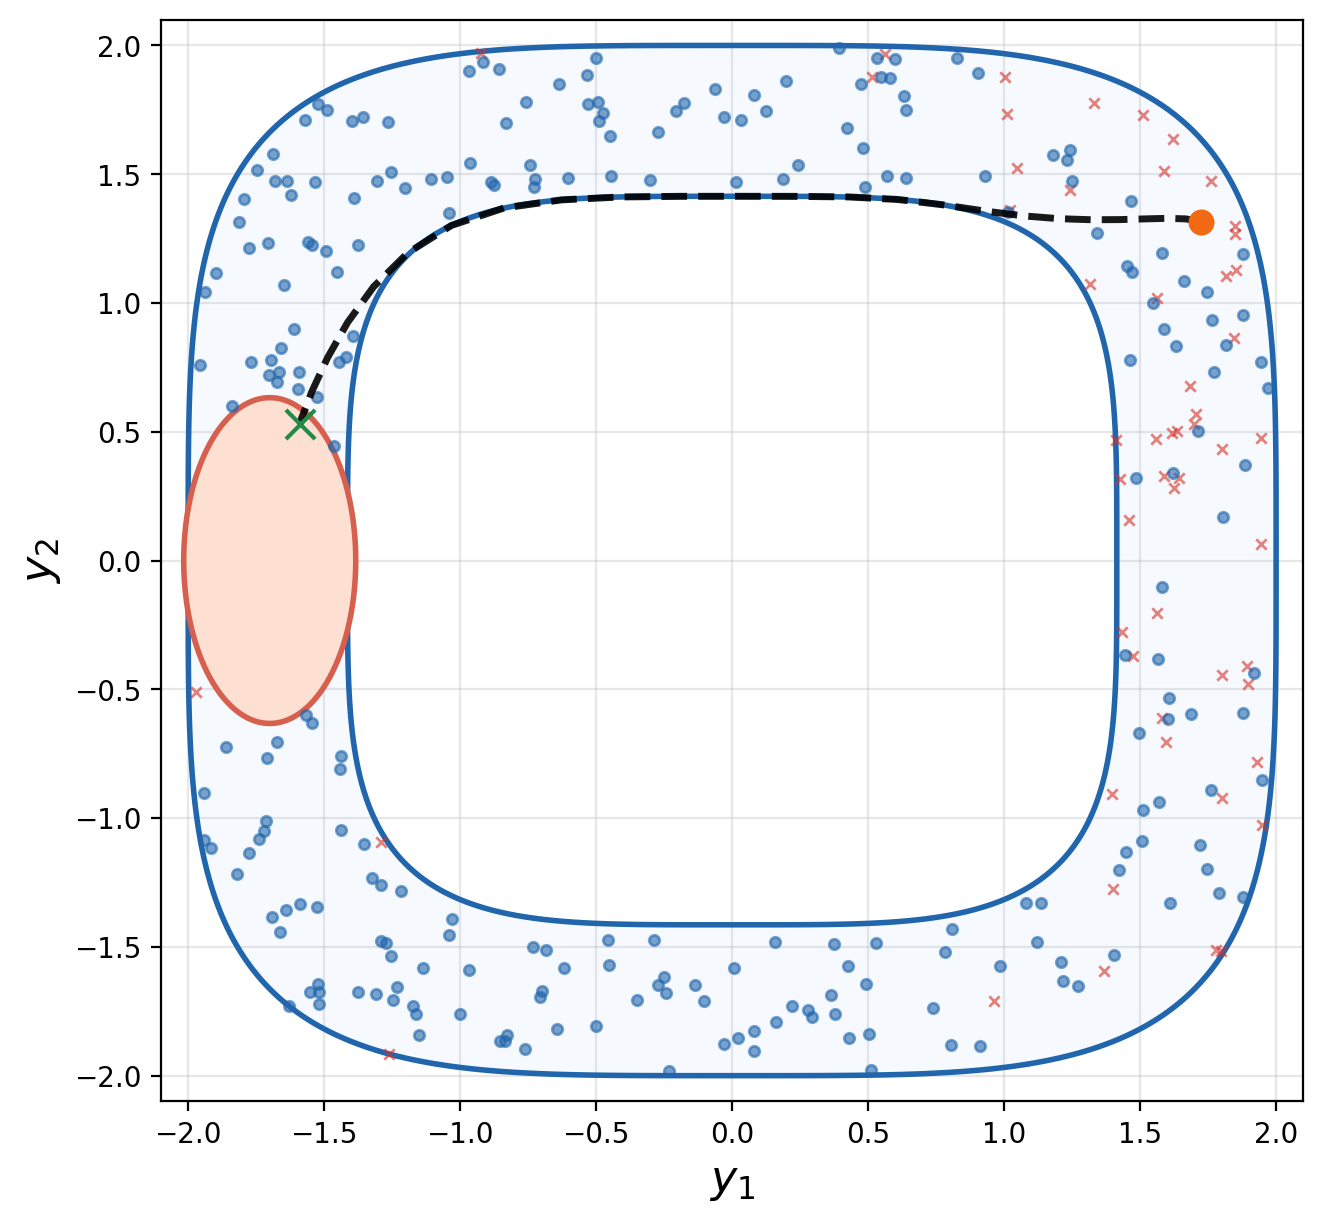

saved fig_dubins_rampc


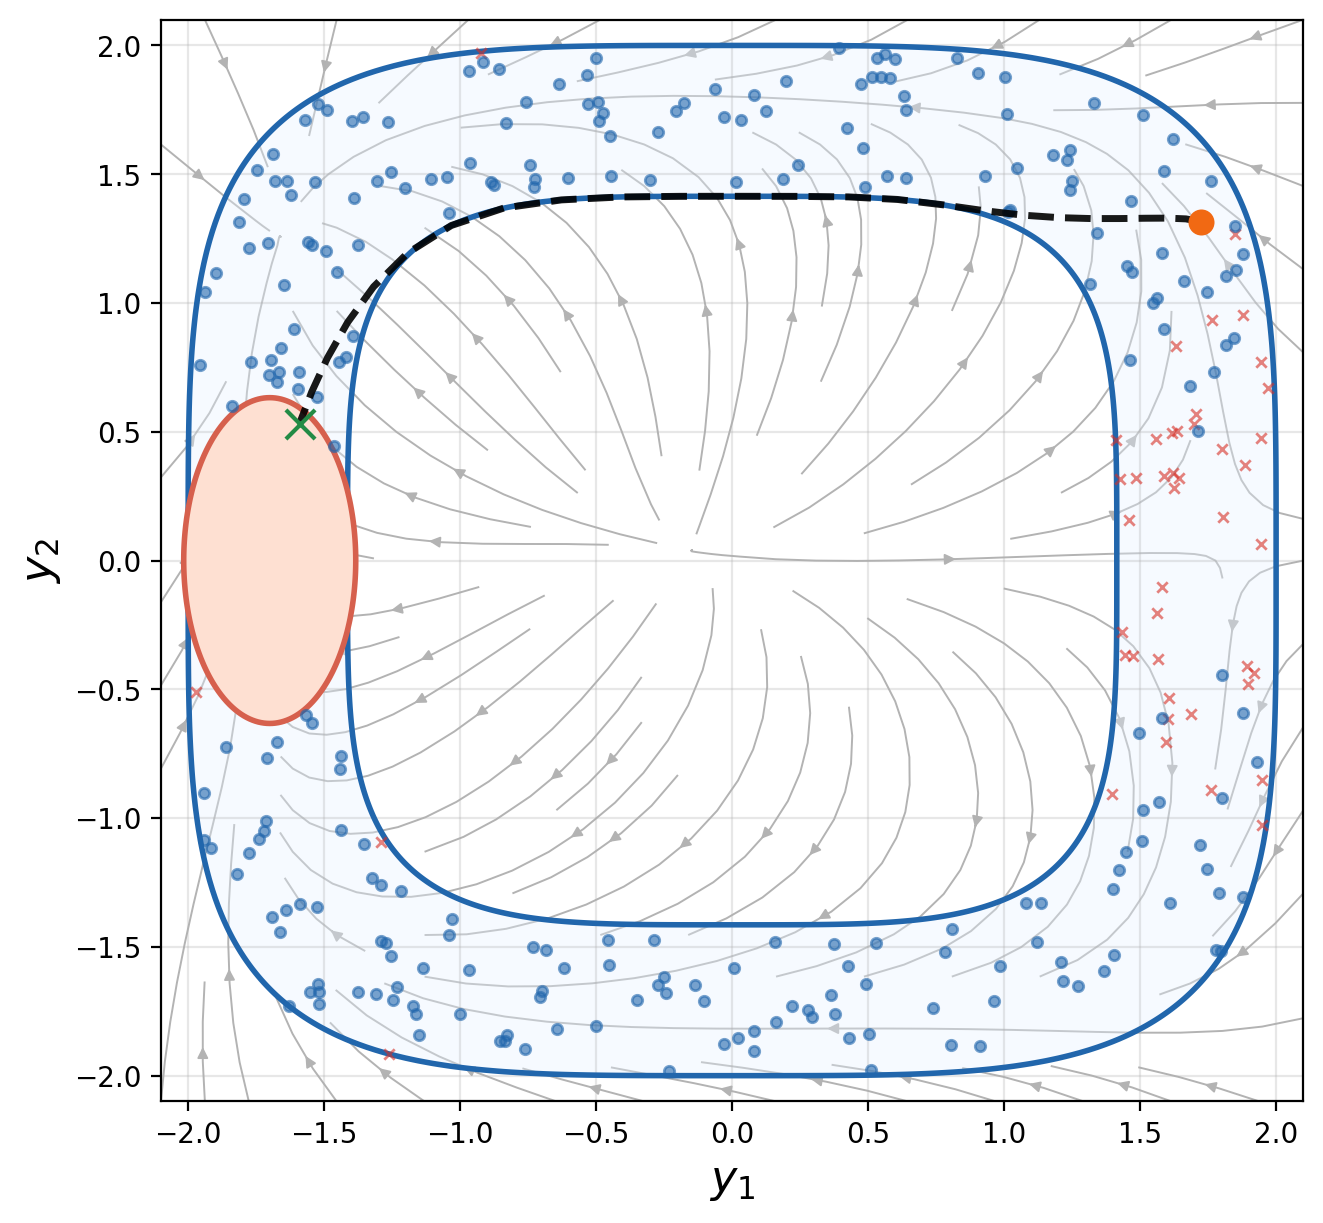

saved fig_dubins_uncon


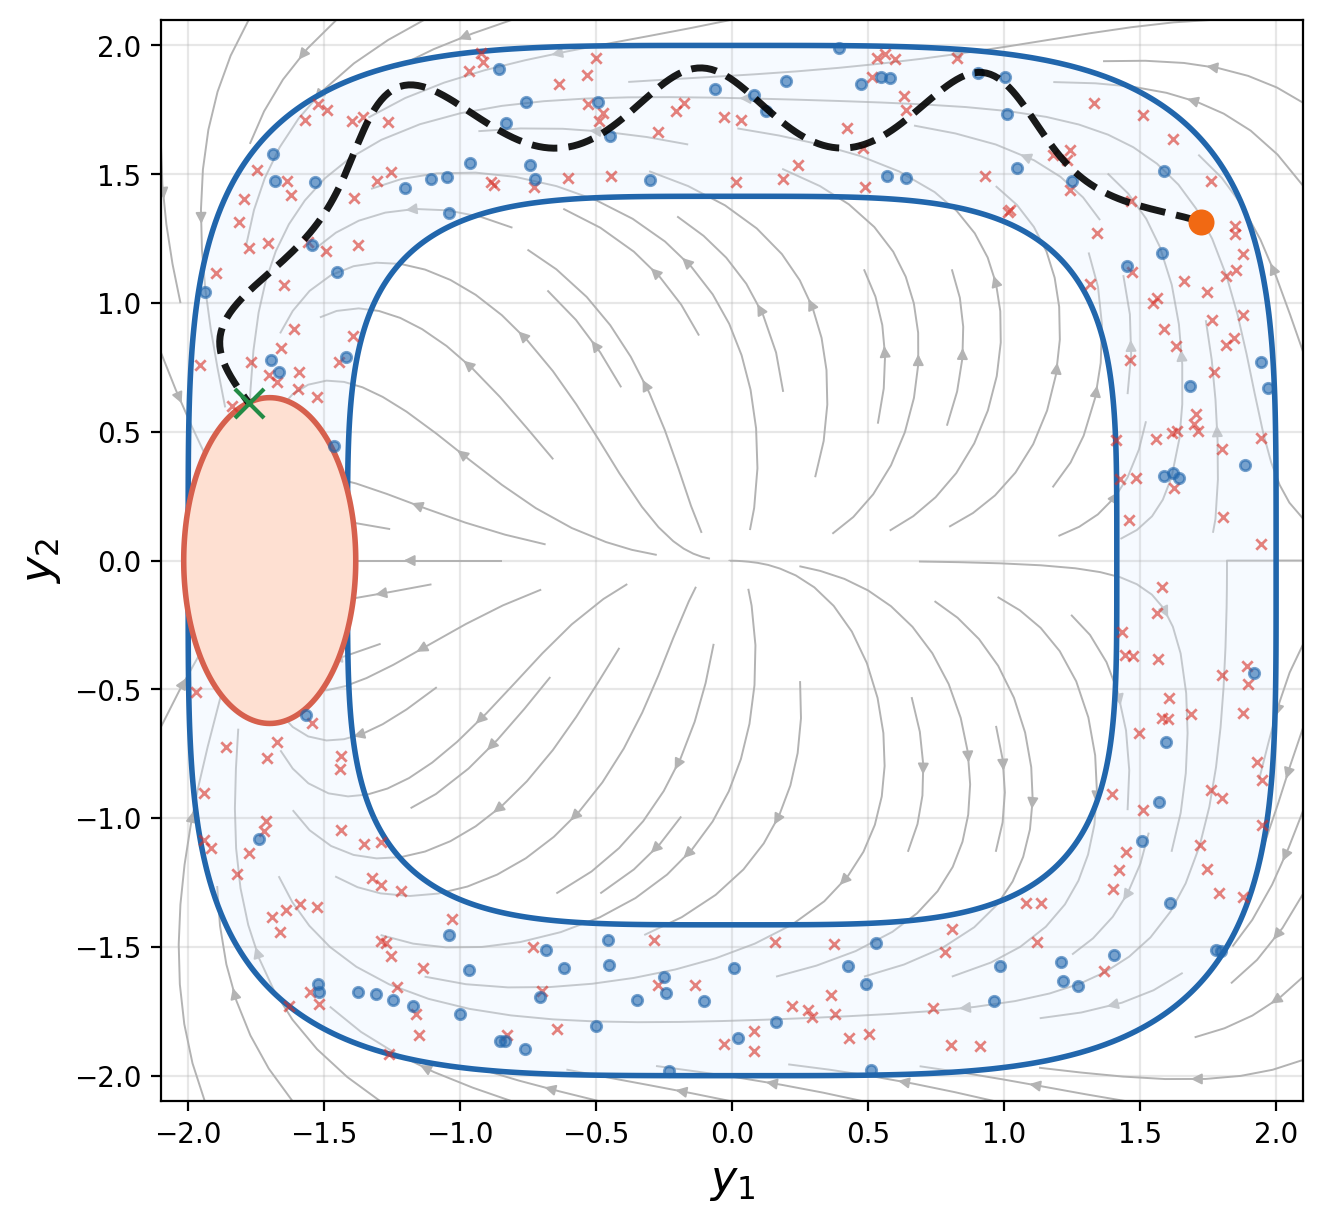

In [13]:
# ── Per-method figures: feasible region + shared-x0 trajectory (+ k1 field) ──
px = 1 / plt.rcParams["figure.dpi"]
_g = np.linspace(-2.1, 2.1, 400)
G1, G2 = np.meshgrid(_g, _g)
Zs, Zt = safe_y_f(G1, G2), target_y_f(G1, G2)
n_vf = 30
y1_vf = np.linspace(-2.1, 2.1, n_vf)
y2_vf = np.linspace(-2.1, 2.1, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(y1_vf, y2_vf)


def draw_sets(ax):
    ax.contourf(
        G1, G2, Zs, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.35, zorder=1
    )
    ax.contour(G1, G2, Zs, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
    ax.contourf(
        G1, G2, Zt, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
    )
    ax.contour(G1, G2, Zt, levels=[0], colors=["#d6604d"], linewidths=2, zorder=4)


def _k1_field(ax, k1opt):
    f = sp.lambdify([y1, y2], list(k1opt), "numpy")
    vals = f(VF_Y1, VF_Y2)
    U = np.broadcast_to(np.asarray(vals[0], float), VF_Y1.shape).astype(float)
    V = np.broadcast_to(np.asarray(vals[1], float), VF_Y1.shape).astype(float)
    ax.streamplot(
        y1_vf,
        y2_vf,
        U,
        V,
        color="0.7",
        linewidth=0.7,
        density=0.9,
        arrowsize=0.8,
        zorder=0,
    )


FIG = {
    "Vanilla MPC": ("fig_dubins_vanilla", None),
    "RA-MPC": ("fig_dubins_rampc", k1_ra),
    "Unconstrained": ("fig_dubins_uncon", k1_unc),
}

for method, (fname, k1opt) in FIG.items():
    mask = feas[method]
    yF = X[:2, candidate_idx[mask]]
    yI = X[:2, candidate_idx[~mask]]
    _, _, xt = TRAJ[method]
    yt = xt[:, :2]
    fig, ax = plt.subplots(figsize=(650 * px, 600 * px), layout="constrained")
    fig.set_dpi(200)
    if k1opt is not None:
        _k1_field(ax, k1opt)
    draw_sets(ax)
    ax.scatter(
        yI[0],
        yI[1],
        s=14,
        c="#d73027",
        marker="x",
        linewidths=1.0,
        alpha=0.6,
        label=f"infeasible: {int((~mask).sum())}",
        zorder=8,
    )
    ax.scatter(
        yF[0],
        yF[1],
        s=14,
        c="#2166ac",
        marker="o",
        alpha=0.6,
        label=f"feasible: {int(mask.sum())}",
        zorder=9,
    )
    ax.plot(yt[:, 0], yt[:, 1], "k--", lw=2.5, alpha=0.9, zorder=12, label="trajectory")
    ax.scatter(
        [yt[0, 0]], [yt[0, 1]], s=70, c="#f16913", marker="o", zorder=15, label="start"
    )
    ax.scatter(
        [yt[-1, 0]],
        [yt[-1, 1]],
        s=110,
        c="#238b45",
        marker="x",
        zorder=15,
        label="target",
    )
    ax.set_xlim(-2.1, 2.1)
    ax.set_ylim(-2.1, 2.1)
    ax.set_xlabel("$y_1$", fontsize=16)
    ax.set_ylabel("$y_2$", fontsize=16)
    # ax.set_title(
    #     f"{method}  —  feasible {100*mask.sum()/len(candidate_idx):.1f}%", fontsize=14
    # )
    # ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(OUTDIR, f"{fname}.{ext}"), dpi=200)
    print("saved", fname)
    plt.show()

In [14]:
# ── RA-MPC success rate vs sampling time dt (fixed dt*N = T_HOR) — cached ─────
sweep_idx = candidate_idx[:N_SWEEP_CAND]


def _sweep_sig():
    import hashlib

    parts = [
        "zoh",
        N_SWEEP_CAND,
        SEED,
        T_HOR,
        T_MAX,
        tuple(DT_SWEEP),
        u1_max,
        u2_max,
        int(
            os.path.getmtime(
                os.path.join(
                    ROOT, "controllers", "sop_bounded_control_dubins_car_result.py"
                )
            )
        ),
    ]
    return hashlib.md5(repr(parts).encode()).hexdigest()


_scache = os.path.join(OUTDIR, "dt_sweep_cache.npz")
sweep_rho = None
if (not RECOMPUTE_FEAS) and os.path.exists(_scache):
    d = np.load(_scache)  # self-written cache; plain arrays + string sig
    if str(d["sig"]) == _sweep_sig():
        sweep_dt, sweep_rho = d["dt"], d["rho"]
        print("loaded cached dt sweep")

if sweep_rho is None:
    print(f"computing RA-MPC dt sweep over {len(sweep_idx)} candidates ...")
    sweep_dt, sweep_rho = [], []
    for dt in DT_SWEEP:
        N = int(round(T_HOR / dt))
        m = np.array(
            Parallel(n_jobs=-1, prefer="processes")(
                delayed(feas_rampc)(X[:, i], dt, N, T_MAX) for i in sweep_idx
            ),
            dtype=bool,
        )
        rho = 100.0 * m.sum() / len(sweep_idx)
        sweep_dt.append(dt)
        sweep_rho.append(rho)
        print(f"  dt={dt:.3f}  N={N:2d}  rho={rho:.1f}%")
    sweep_dt, sweep_rho = np.array(sweep_dt), np.array(sweep_rho)
    np.savez(_scache, sig=_sweep_sig(), dt=sweep_dt, rho=sweep_rho)

loaded cached dt sweep


saved fig_dubins_compare


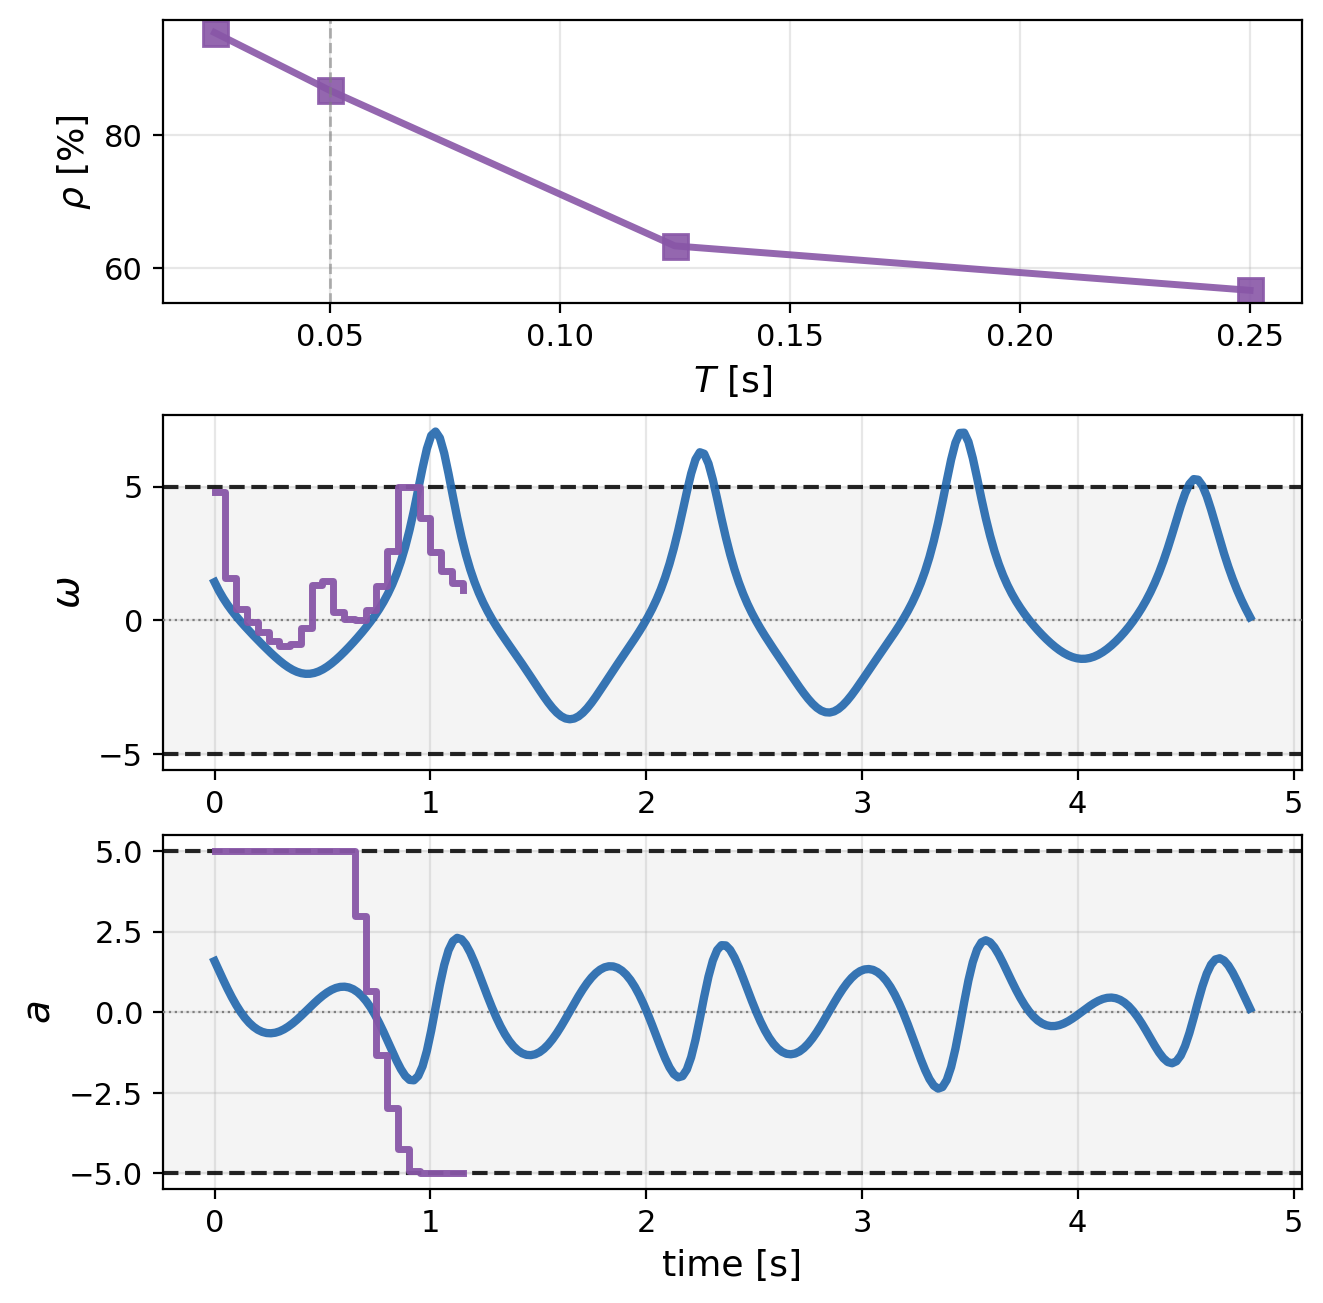

In [19]:
# ── Combined figure: dt-sweep success rate (top) + control comparison (uncon vs RA-MPC)
tu, uu_u, _ = TRAJ["Unconstrained"]  # continuous unconstrained control
tr, uu_r, _ = TRAJ["RA-MPC"]  # RA-MPC ZOH (piecewise-constant) control
col_unc, col_ra = "#2166ac", "#8856a7"

fig, (axR, axW, axA) = plt.subplots(
    3,
    1,
    figsize=(650 * px, 640 * px),
    layout="constrained",
    gridspec_kw={"height_ratios": [0.8, 1.0, 1.0]},
)
fig.set_dpi(200)

# top: RA-MPC success rate vs sampling time T = dt
axR.plot(sweep_dt, sweep_rho, color=col_ra, marker="s", lw=2.5, ms=9, alpha=0.9)
axR.axvline(DT_BASE, color="gray", lw=1, ls="--", alpha=0.6)
axR.set_xlabel("$T$ [s]", fontsize=13)
axR.set_ylabel(r"$\rho$ [%]", fontsize=13)
axR.tick_params(labelsize=11)
axR.grid(True, alpha=0.3)

# bottom two: control comparison from the shared x0
for ax, ch, ub, lbl in zip((axW, axA), (0, 1), U_MAX, (r"$\omega$", r"$a$")):
    ax.axhspan(-ub, ub, color="#f0f0f0", alpha=0.7, zorder=0)
    ax.axhline(ub, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(-ub, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(0, color="gray", lw=0.8, ls=":", zorder=4)
    ax.plot(
        tu,
        uu_u[:, ch],
        color=col_unc,
        lw=3,
        alpha=0.9,
        zorder=10,
        label="unconstrained",
    )
    if len(uu_r) > 0:
        ax.step(
            tr[:-1],
            uu_r[:, ch],
            where="post",
            color=col_ra,
            lw=2.5,
            alpha=0.95,
            zorder=11,
            label="RA-MPC",
        )
    ax.set_ylabel(lbl, fontsize=14)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)
axA.set_xlabel("time [s]", fontsize=13)
# axW.legend(fontsize=10, loc="upper right")

for ext in ("pdf", "png"):
    fig.savefig(os.path.join(OUTDIR, f"fig_dubins_compare.{ext}"), dpi=200)
print("saved fig_dubins_compare")
plt.show()

## Summary

Saved to `figures/` (each as `.pdf` + `.png`):

- `fig_dubins_vanilla`, `fig_dubins_rampc`, `fig_dubins_uncon` — per-method feasible
  region + the shared-x0 closed-loop trajectory (k1 field overlaid for the two
  reach-avoid methods).
- `fig_dubins_compare` — RA-MPC success rate vs sampling time (top) and the u1/u2 control
  comparison (unconstrained continuous vs RA-MPC piecewise-constant) from the shared x0.

The unconstrained controller's inputs leave the `±5` band (it enforces no bounds), while
RA-MPC stays inside — the point of the control comparison.

A benchmark cell also reports the **average single-step MPC solve time** (ms/step) for
vanilla MPC and RA-MPC, timed over a few receding closed-loop rollouts.

Feasibility and dt-sweep results are cached under `figures/`; set `RECOMPUTE_FEAS = True`
to refresh.
